<h1>Exploratory Data Analysis</h1>

In [3]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import hashlib, io, os, random, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imagehash
from PIL import Image
from tqdm.auto import tqdm

ROOT = Path.cwd()
DATA = ROOT / "datasets" / "datasets"
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}
SPLITS = ["train", "val", "test"]
CLASSES = ["cat", "dog"]

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 140)

assert DATA.exists(), f"Dataset folder not found: {DATA}"

<h2>Data Count</h2>

,train,val
cat,10000,2500
dog,10000,2500
total,20000,5000


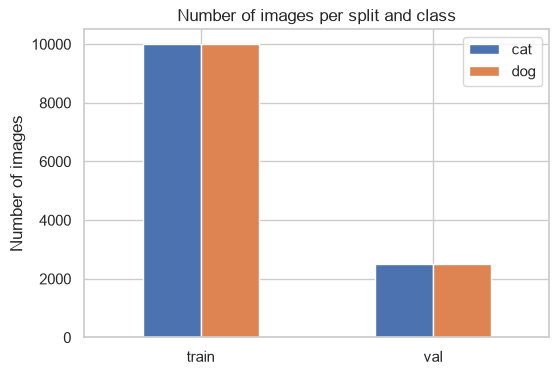

In [4]:
# Store the counts in a dictionary: {"train": {"cat": ..., "dog": ...}, "val": {...}}
counts = {}
for split in ["train", "val"]:
    counts[split] = {}
    for animal in CLASSES:
        counts[split][animal] = len(list((DATA / split / animal).glob("*.jpg")))

# Turn it into a table: rows = cat/dog, columns = train/val
table = pd.DataFrame(counts)
table.loc["total"] = table.sum()          # add a "total" row that adds up each column
display(table)

# Bar chart
table.drop("total").T.plot(kind="bar", figsize=(6, 4), rot=0)
plt.title("Number of images per split and class")
plt.ylabel("Number of images")
plt.show()


In [5]:
# Go through every train and val image and record its width and height

rows = []   # each item will describe one image, e.g. {"split": "train", "class": "cat", "width": 500, "height": 374}

for split in ["train", "val"]:
    for animal in CLASSES:
        folder = DATA / split / animal
        image_paths = list(folder.glob("*.jpg"))

        # tqdm shows a progress bar, since there are 25,000 images
        for path in tqdm(image_paths, desc=f"{split}/{animal}"):
            with Image.open(path) as img:     # only reads the file header, so it's fast
                width, height = img.size      # img.size is (width, height) in pixels
                mode = img.mode
            rows.append({"split": split, "class": animal, "width": width, "height": height,
                         "mode": mode})       # NEW: store the mode too

sizes = pd.DataFrame(rows)    # turn the list into a table: one row per image
print(f"Collected sizes for {len(sizes)} images")
sizes.head()                  # show the first 5 rows

train/cat:   0%|          | 0/10000 [00:00<?, ?it/s]

train/dog:   0%|          | 0/10000 [00:00<?, ?it/s]

val/cat:   0%|          | 0/2500 [00:00<?, ?it/s]

val/dog:   0%|          | 0/2500 [00:00<?, ?it/s]

Collected sizes for 25000 images


,split,class,width,height,mode
0,train,cat,500,374,RGB
1,train,cat,300,280,RGB
2,train,cat,489,499,RGB
3,train,cat,500,374,RGB
4,train,cat,499,471,RGB


<h2>Width and Height Distribution</h2>

In [6]:
# Summary statistics, calculated separately for train and val
for split in ["train", "val"]:
    part = sizes[sizes["split"] == split]      # keep only the rows belonging to this split
    print(f"--- {split} ({len(part)} images) ---")
    print(part[["width", "height"]].describe().round(1))
    print()                                    # blank line between the two tables


--- train (20000 images) ---
         width   height
count  20000.0  20000.0
mean     404.3    361.0
std      108.9     96.9
min       42.0     32.0
25%      323.0    302.0
50%      448.0    374.0
75%      499.0    421.0
max     1050.0    768.0

--- val (5000 images) ---
        width  height
count  5000.0  5000.0
mean    403.1   358.3
std     109.5    97.3
min      51.0    37.0
25%     320.0   300.0
50%     447.0   374.0
75%     499.0   417.0
max     500.0   500.0



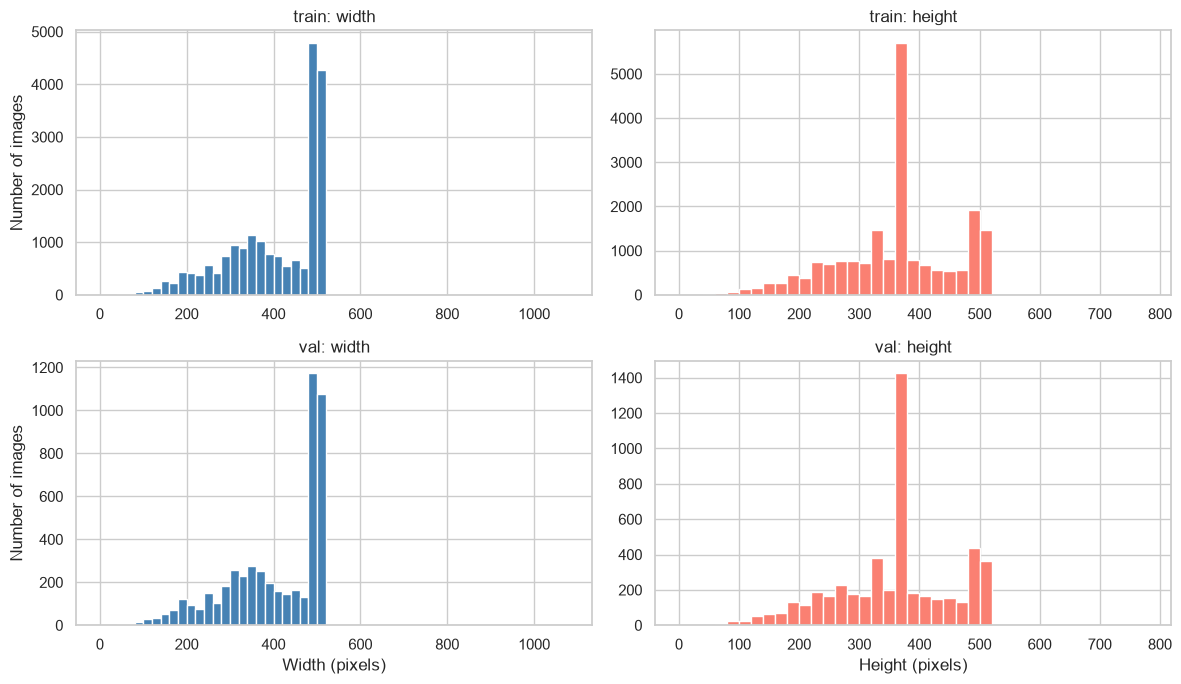

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))   # 2 rows (train, val) x 2 columns (width, height)

# Use the SAME bar ranges for both splits, so the charts can be compared fairly
width_bins = range(0, 1100, 20)    # bars of 20 px: 0-20, 20-40, ... up to 1100
height_bins = range(0, 800, 20)

for row, split in enumerate(["train", "val"]):     # row 0 = train, row 1 = val
    part = sizes[sizes["split"] == split]

    axes[row, 0].hist(part["width"], bins=width_bins, color="steelblue")
    axes[row, 0].set_title(f"{split}: width")
    axes[row, 0].set_ylabel("Number of images")

    axes[row, 1].hist(part["height"], bins=height_bins, color="salmon")
    axes[row, 1].set_title(f"{split}: height")

axes[1, 0].set_xlabel("Width (pixels)")
axes[1, 1].set_xlabel("Height (pixels)")
plt.tight_layout()
plt.show()

In [8]:
# Make the "500 x 374"-style label column (in case you haven't run that cell yet)
sizes["size"] = sizes["width"].astype(str) + " x " + sizes["height"].astype(str)

for split in ["train", "val"]:
    part = sizes[sizes["split"] == split]
    top = part["size"].value_counts().head(5)       # 5 most common sizes in this split

    print(f"--- {split}: top 5 sizes ({len(part)} images) ---")
    for size_label, count in top.items():            # .items() gives (label, count) pairs
        percent = count / len(part)
        print(f"{size_label:>10}: {count:5d} images ({percent:.1%})")
    print()

--- train: top 5 sizes (20000 images) ---
 500 x 374:  2362 images (11.8%)
 499 x 375:  2334 images (11.7%)
 375 x 499:   207 images (1.0%)
 499 x 333:   175 images (0.9%)
 374 x 500:   171 images (0.9%)

--- val: top 5 sizes (5000 images) ---
 500 x 374:   593 images (11.9%)
 499 x 375:   578 images (11.6%)
 374 x 500:    56 images (1.1%)
 499 x 333:    54 images (1.1%)
 375 x 499:    54 images (1.1%)



In [9]:
# Percentage of each size within its own split
train_pct = sizes[sizes["split"] == "train"]["size"].value_counts(normalize=True) * 100
val_pct = sizes[sizes["split"] == "val"]["size"].value_counts(normalize=True) * 100

comparison = pd.DataFrame({"train %": train_pct, "val %": val_pct})
comparison = comparison.loc[train_pct.index[:5]].round(1)    # keep train's top 5 sizes
comparison

,train %,val %
size,,
500 x 374,11.8,11.9
499 x 375,11.7,11.6
375 x 499,1.0,1.1
499 x 333,0.9,1.1
374 x 500,0.9,1.1


<h2>Aspect Ratio</h2>

In [10]:
# Aspect ratio = width / height
#   > 1  -> landscape (wider than tall), e.g. 4:3 = 1.33
#   = 1  -> square
#   < 1  -> portrait (taller than wide)
sizes["aspect_ratio"] = sizes["width"] / sizes["height"]

for split in ["train", "val"]:
    part = sizes[sizes["split"] == split]
    print(f"--- {split} ({len(part)} images) ---")
    print(part["aspect_ratio"].describe().round(2))
    print()

--- train (20000 images) ---
count    20000.00
mean         1.16
std          0.29
min          0.31
25%          0.93
50%          1.27
75%          1.34
max          5.91
Name: aspect_ratio, dtype: float64

--- val (5000 images) ---
count    5000.00
mean        1.16
std         0.29
min         0.37
25%         0.94
50%         1.28
75%         1.34
max         2.70
Name: aspect_ratio, dtype: float64



In [11]:
# Put each image into a simple category based on its aspect ratio
def shape_category(ratio):
    if ratio > 1.05:
        return "landscape"
    elif ratio < 0.95:
        return "portrait"
    else:
        return "square"          # between 0.95 and 1.05 counts as (roughly) square

sizes["shape"] = sizes["aspect_ratio"].apply(shape_category)   # run the function on every row

# Count categories per split, as percentages
shape_table = pd.crosstab(sizes["shape"], sizes["split"], normalize="columns") * 100
shape_table.round(1)

split,train,val
shape,,
landscape,63.7,64.5
portrait,26.6,25.6
square,9.6,9.9


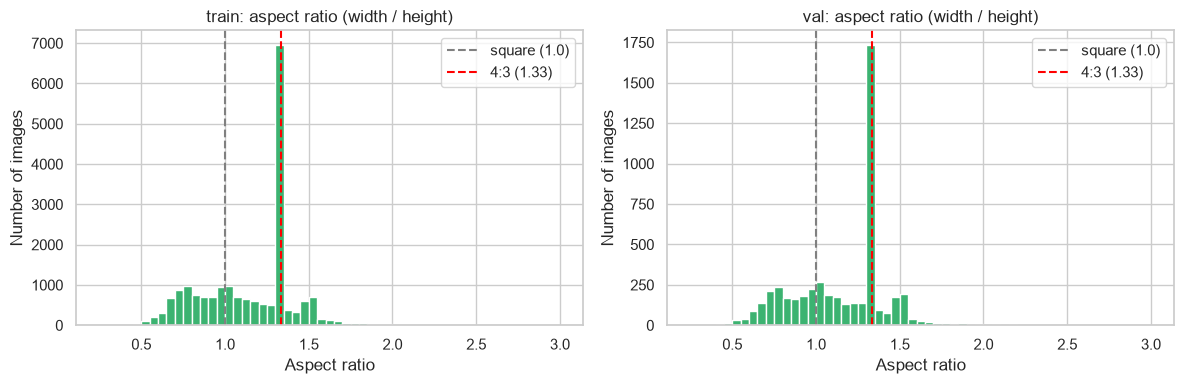

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
ratio_bins = [x / 20 for x in range(5, 61)]     # bars of width 0.05, from 0.25 to 3.0

for col, split in enumerate(["train", "val"]):
    part = sizes[sizes["split"] == split]
    axes[col].hist(part["aspect_ratio"], bins=ratio_bins, color="mediumseagreen")
    axes[col].axvline(1.0, color="grey", linestyle="--", label="square (1.0)")    # reference lines
    axes[col].axvline(4/3, color="red", linestyle="--", label="4:3 (1.33)")
    axes[col].set_title(f"{split}: aspect ratio (width / height)")
    axes[col].set_xlabel("Aspect ratio")
    axes[col].set_ylabel("Number of images")
    axes[col].legend()

plt.tight_layout()
plt.show()

<h2>RGB</h2>

In [13]:
# Colour modes:
#   RGB  = normal colour image (3 channels: red, green, blue)
#   L    = grayscale (1 channel)
#   RGBA = colour + transparency (4 channels)
#   CMYK = print colour format (4 channels)
#   P    = palette image (like GIFs)
for split in ["train", "val"]:
    part = sizes[sizes["split"] == split]
    print(f"--- {split} ---")
    print(part["mode"].value_counts())
    print()

if (sizes["mode"] == "RGB").all():
    print("All train and val images are RGB")
else:
    print("Some images are NOT RGB; convert them with .convert('RGB') when loading")

--- train ---
mode
RGB    20000
Name: count, dtype: int64

--- val ---
mode
RGB    5000
Name: count, dtype: int64

All train and val images are RGB


<h1>Data Preprocessing</h1>

In [14]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ---- Settings (change these in one place) ----
SEED = 42
TRAIN_PER_CLASS = 5000   # 5000 cats + 5000 dogs = 10,000 training images
VAL_PER_CLASS = 1500     # 1500 cats + 1500 dogs = 3,000 validation images
IMG_SIZE = 224
BATCH_SIZE = 32

def set_seed(seed):
    """Fix all randomness so results can be reproduced."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [15]:
#IMAGENET_MEAN = [0.485, 0.456, 0.406]
#IMAGENET_STD = [0.229, 0.224, 0.225]
MEAN_FILL = (124, 116, 104)  

# Training: random augmentation, so each epoch sees different versions
train_transform = transforms.Compose([
    transforms.RandomRotation(15, interpolation=transforms.InterpolationMode.BILINEAR, fill=MEAN_FILL),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),       # scaling
    transforms.RandomHorizontalFlip(p=0.5),                          # flipping
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),                                           # 0-255 -> 0-1
    #transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),               # standardise
])

# Validation / test: fixed, no randomness
eval_transform = transforms.Compose([
    transforms.Resize(256),              # shorter side -> 256, keeps aspect ratio
    transforms.CenterCrop(IMG_SIZE),     # centre 224x224
    transforms.ToTensor(),
    #transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [16]:
# ImageFolder reads the images and uses the folder name as the label
full_train = datasets.ImageFolder(DATA / "train", transform=train_transform)
full_val = datasets.ImageFolder(DATA / "val", transform=eval_transform)

print("Class to label mapping:", full_train.class_to_idx)
assert full_train.class_to_idx == {"cat": 0, "dog": 1}, "labels must be cat=0, dog=1"
print(f"Full train: {len(full_train)} images, full val: {len(full_val)} images")

Class to label mapping: {'cat': 0, 'dog': 1}
Full train: 20000 images, full val: 5000 images


In [17]:
def pick_per_class(dataset, n_per_class, seed):
    """Randomly pick n images from each class. Same seed -> same images every time."""
    rng = np.random.default_rng(seed)             # our own random number generator
    labels = np.array(dataset.targets)            # the label (0 or 1) of every image
    chosen = []
    for class_label in [0, 1]:                    # 0 = cat, 1 = dog
        positions = np.where(labels == class_label)[0]                   # where this class sits in the list
        picked = rng.choice(positions, size=n_per_class, replace=False)  # random, no repeats
        chosen.extend(picked.tolist())
    return sorted(chosen)

train_indices = pick_per_class(full_train, TRAIN_PER_CLASS, SEED)
val_indices = pick_per_class(full_val, VAL_PER_CLASS, SEED)

train_set = Subset(full_train, train_indices)     # a "view" containing only the chosen images
val_set = Subset(full_val, val_indices)

# Check sizes and balance
train_labels = [full_train.targets[i] for i in train_indices]
val_labels = [full_val.targets[i] for i in val_indices]
print(f"Train subset: {len(train_set)} images (cats: {train_labels.count(0)}, dogs: {train_labels.count(1)})")
print(f"Val subset:   {len(val_set)} images (cats: {val_labels.count(0)}, dogs: {val_labels.count(1)})")


Train subset: 10000 images (cats: 5000, dogs: 5000)
Val subset:   3000 images (cats: 1500, dogs: 1500)


In [18]:
g = torch.Generator()
g.manual_seed(SEED)          # makes the shuffle order reproducible

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True, generator=g)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True, persistent_workers=True)

print(f"Train batches per epoch: {len(train_loader)}, val batches: {len(val_loader)}")


Train batches per epoch: 313, val batches: 94


In [19]:
# Safety check: train and val batches must be on the same scale
train_images, _ = next(iter(train_loader))
val_images, _ = next(iter(val_loader))
print(f"train pixels: {train_images.min():.2f} to {train_images.max():.2f}")
print(f"val pixels:   {val_images.min():.2f} to {val_images.max():.2f}")
assert abs(train_images.min().item() - val_images.min().item()) < 0.5, "Train and val preprocessing differ!"

train pixels: 0.00 to 1.00
val pixels:   0.00 to 1.00


In [20]:
images, labels = next(iter(train_loader))     # grab one batch
print("Images:", images.shape)                 # expect [64, 3, 224, 224]
print("Labels:", labels[:10].tolist(), "...")  # 0 = cat, 1 = dog
print(f"Pixel range after normalising: {images.min():.2f} to {images.max():.2f}")  # about -2.1 to 2.6


Images: torch.Size([32, 3, 224, 224])
Labels: [0, 0, 1, 0, 1, 1, 0, 0, 1, 1] ...
Pixel range after normalising: 0.00 to 1.00


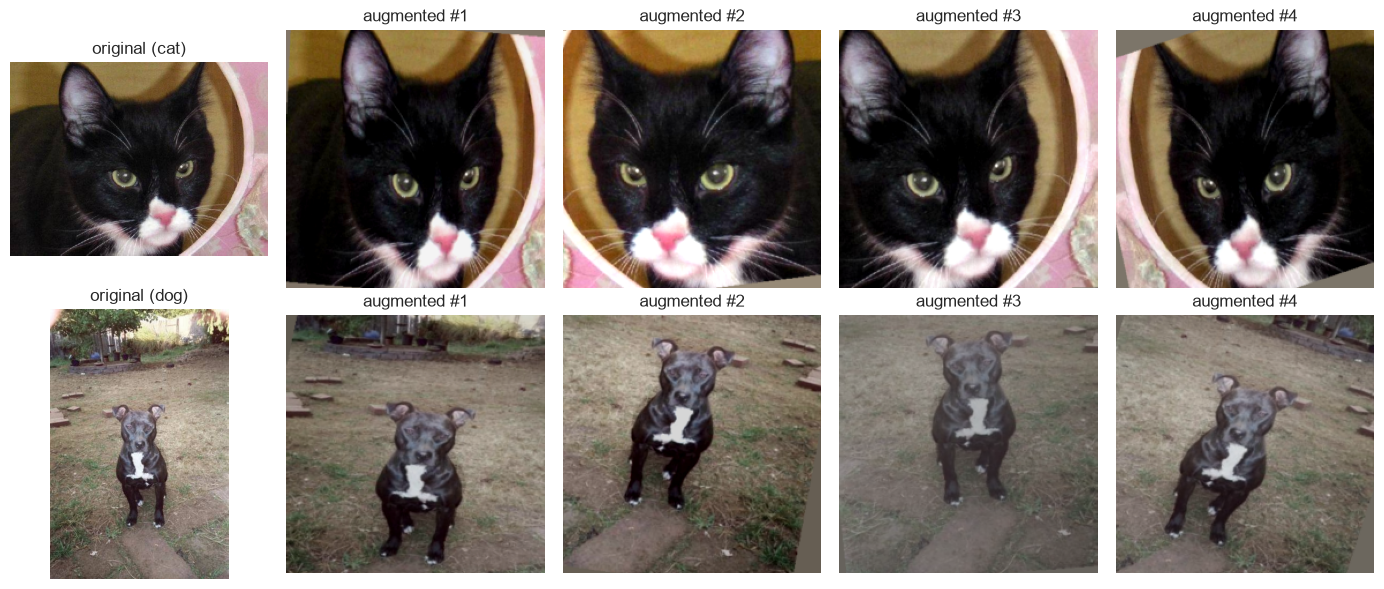

In [21]:
def to_displayable(tensor):
    """Tensor (C,H,W) in 0-1 -> array (H,W,C) that plt.imshow can show."""
    return tensor.clamp(0, 1).permute(1, 2, 0).numpy()

raw_train = datasets.ImageFolder(DATA / "train")         # no transform, gives the original images
examples = [train_indices[0], train_indices[-1]]         # one cat, one dog from your subset

fig, axes = plt.subplots(len(examples), 5, figsize=(14, 6))
for row, idx in enumerate(examples):
    img, label = raw_train[idx]
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"original ({raw_train.classes[label]})")
    for col in range(1, 5):
        axes[row, col].imshow(to_displayable(train_transform(img)))   # a new random version each time
        axes[row, col].set_title(f"augmented #{col}")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()


In [22]:
images, labels = next(iter(train_loader))
print("One batch:", tuple(images.shape))          # (64, 3, 224, 224) = batch, channels, height, width

one_image = images[0]                             # the first image in the batch
channels, height, width = one_image.shape
print(f"One image: {tuple(one_image.shape)} -> {height} x {width} pixels, {channels} colour channels")
print("Same image in H, W, C order:", tuple(one_image.permute(1, 2, 0).shape))   # (224, 224, 3)

# Validation images too
val_image, val_label = val_set[0]
print("One validation image:", tuple(val_image.shape))                            # (3, 224, 224)

assert one_image.shape == (3, 224, 224) and val_image.shape == (3, 224, 224)
print("Input size confirmed: 224 x 224 x 3")


One batch: (32, 3, 224, 224)
One image: (3, 224, 224) -> 224 x 224 pixels, 3 colour channels
Same image in H, W, C order: (224, 224, 3)
One validation image: (3, 224, 224)
Input size confirmed: 224 x 224 x 3


<h1>Building the CNN Model</h1>

In [23]:
import torch.nn as nn

class CustomCNN(nn.Module):
    """Simple 3-layer CNN: 3 x (Conv -> ReLU -> MaxPool), then Flatten -> Dense(128) -> Dropout -> output."""
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),   nn.ReLU(inplace=True), nn.MaxPool2d(2),   # 224 -> 222 -> 111
            nn.Conv2d(32, 64, kernel_size=3),  nn.ReLU(inplace=True), nn.MaxPool2d(2),   # 111 -> 109 -> 54
            nn.Conv2d(64, 128, kernel_size=3), nn.ReLU(inplace=True), nn.MaxPool2d(2),   # 54  -> 52  -> 26
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                            # 128 x 26 x 26 -> 86,528
            nn.Linear(128 * 26 * 26, 128),           # hidden dense layer
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),             # output: 2 scores (cat, dog)
        )
        self._init_weights()

    def _init_weights(self):
        """Kaiming (He) initialisation for layers followed by ReLU; small random values for the output layer."""
        output_layer = self.classifier[-1]                  # the final Linear(128 -> 2)
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                if m is output_layer:
                    nn.init.normal_(m.weight, mean=0, std=0.01)       # no ReLU after it, so small values
                else:
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)                                # biases start at 0


    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [24]:
set_seed(SEED)                       # same starting weights every run
model = CustomCNN().to(device)

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device)   # 2 fake images
x = dummy
for i, layer in enumerate(model.features, start=1):
    x = layer(x)
    print(f"layer {i} ({layer.__class__.__name__}): {tuple(x.shape)}")   # show the layer type too
print("final output:", tuple(model(dummy).shape))               # expect (2, 2)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")                     # about 11.2 million


layer 1 (Conv2d): (2, 32, 222, 222)
layer 2 (ReLU): (2, 32, 222, 222)
layer 3 (MaxPool2d): (2, 32, 111, 111)
layer 4 (Conv2d): (2, 64, 109, 109)
layer 5 (ReLU): (2, 64, 109, 109)
layer 6 (MaxPool2d): (2, 64, 54, 54)
layer 7 (Conv2d): (2, 128, 52, 52)
layer 8 (ReLU): (2, 128, 52, 52)
layer 9 (MaxPool2d): (2, 128, 26, 26)
final output: (2, 2)
Trainable parameters: 11,169,218


<h1>Training the model</h1>

In [25]:
set_seed(SEED)
model = CustomCNN().to(device)
model.train()

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
loss = nn.CrossEntropyLoss()(outputs, labels)
loss.backward()

print("Output shape:", tuple(outputs.shape))                        # expect (64, 2)
print(f"Loss before training: {loss.item():.3f}  (about 0.69 = random guessing)")
print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB of 8 GB")


Output shape: (32, 2)
Loss before training: 0.706  (about 0.69 = random guessing)
Peak GPU memory: 0.86 GB of 8 GB


In [26]:
import time

EPOCHS = 50            # maximum passes through the training data
LEARNING_RATE = 1e-3   # size of each weight update (a common starting value for Adam)
WEIGHT_DECAY = 1e-4    # small penalty on large weights, reduces overfitting
PATIENCE = 10           # stop if val accuracy hasn't improved for 10 epochs in a row

MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)          # create the folder if it doesn't exist
RUN_NAME = "baseline_3conv"                          # change this for every experiment
BEST_MODEL_PATH = MODEL_DIR / f"{RUN_NAME}_best.pt"

g = torch.Generator()
g.manual_seed(SEED)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True, generator=g)

set_seed(SEED)
model = CustomCNN().to(device)                        # a fresh, untrained model
loss_fn = nn.CrossEntropyLoss()                       # compares the 2 scores with the true label
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# If val loss doesn't improve for 2 epochs, halve the learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

In [27]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    """One pass over the training data, learning from every batch. Returns (average loss, accuracy)."""
    model.train()                                     # training mode: dropout ON, BatchNorm uses batch stats
    total_loss, correct, seen = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)   # move the batch to the GPU

        outputs = model(images)                       # 1. forward pass: predict scores
        loss = loss_fn(outputs, labels)               # 2. how wrong were we?
        optimizer.zero_grad()                         # 3. clear the previous batch's gradients
        loss.backward()                               # 4. work out how to change each weight (backpropagation)
        optimizer.step()                              # 5. update the weights a little

        total_loss += loss.item() * labels.size(0)    # loss.item() is the batch average, so x batch size
        predictions = outputs.argmax(dim=1)           # predicted class = whichever score is higher
        correct += (predictions == labels).sum().item()
        seen += labels.size(0)

    return total_loss / seen, correct / seen


@torch.no_grad()                                      # no learning here, so skip gradients (faster, less memory)
def evaluate(model, loader, loss_fn):
    """Measure loss and accuracy without learning. Returns (average loss, accuracy)."""
    model.eval()                                      # evaluation mode: dropout OFF, BatchNorm uses running stats
    total_loss, correct, seen = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        total_loss += loss_fn(outputs, labels).item() * labels.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        seen += labels.size(0)

    return total_loss / seen, correct / seen


<h1>Training + Validation</h1>

In [52]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc = 0.0
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn)
    scheduler.step(val_loss)                          # may lower the learning rate
    current_lr = optimizer.param_groups[0]["lr"]

    # record this epoch's results
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    # save the model whenever validation accuracy reaches a new best
    note = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)   # state_dict = all the learned weights
        note = "  <- best so far, saved"
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch:2d}/{EPOCHS} | train loss {train_loss:.4f}, acc {train_acc:.2%} | "
          f"val loss {val_loss:.4f}, acc {val_acc:.2%} | lr {current_lr:.1e} | {time.time() - start:.0f}s{note}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping: val accuracy hasn't improved for {PATIENCE} epochs.")
        break

print(f"\nBest validation accuracy: {best_val_acc:.2%}")


Epoch  1/50 | train loss 0.6993, acc 58.01% | val loss 0.6276, acc 65.83% | lr 1.0e-03 | 41s  <- best so far, saved
Epoch  2/50 | train loss 0.6304, acc 64.65% | val loss 0.5824, acc 68.67% | lr 1.0e-03 | 33s  <- best so far, saved
Epoch  3/50 | train loss 0.6031, acc 67.68% | val loss 0.5565, acc 71.90% | lr 1.0e-03 | 32s  <- best so far, saved
Epoch  4/50 | train loss 0.5735, acc 70.55% | val loss 0.5172, acc 74.83% | lr 1.0e-03 | 33s  <- best so far, saved
Epoch  5/50 | train loss 0.5382, acc 73.68% | val loss 0.4815, acc 77.07% | lr 1.0e-03 | 31s  <- best so far, saved
Epoch  6/50 | train loss 0.5125, acc 75.39% | val loss 0.4507, acc 79.53% | lr 1.0e-03 | 30s  <- best so far, saved
Epoch  7/50 | train loss 0.4917, acc 76.58% | val loss 0.4622, acc 77.67% | lr 1.0e-03 | 31s
Epoch  8/50 | train loss 0.4771, acc 77.49% | val loss 0.4137, acc 80.57% | lr 1.0e-03 | 31s  <- best so far, saved
Epoch  9/50 | train loss 0.4585, acc 78.70% | val loss 0.4295, acc 80.03% | lr 1.0e-03 | 33s
Ep

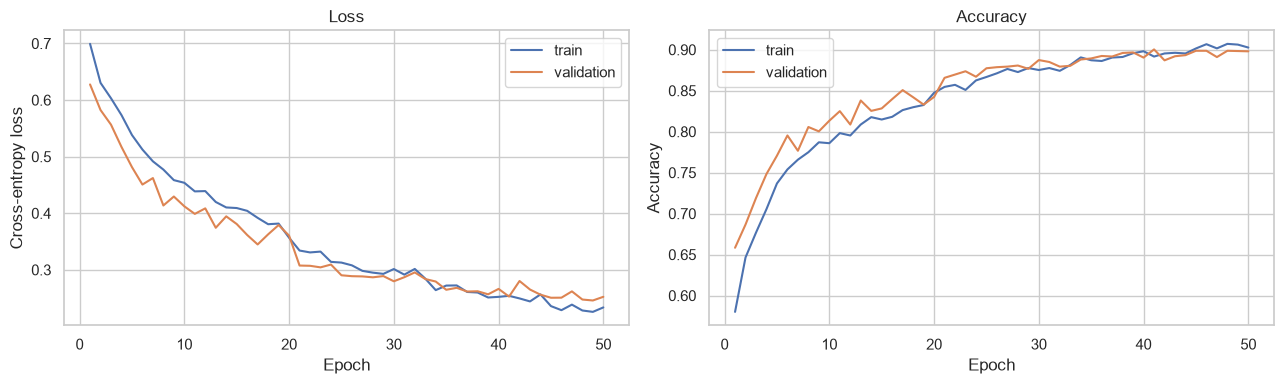

In [54]:
n_epochs = len(history["train_loss"])
history_df = pd.DataFrame(history, index=range(1, n_epochs + 1))
history_df.to_csv(MODEL_DIR / f"{RUN_NAME}_history.csv", index_label="epoch")   # keep the numbers for the report

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_df.index, history_df["train_loss"], label="train")
axes[0].plot(history_df.index, history_df["val_loss"], label="validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[0].legend()

axes[1].plot(history_df.index, history_df["train_acc"], label="train")
axes[1].plot(history_df.index, history_df["val_acc"], label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


In [55]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

CLASS_NAMES = ["cat", "dog"]                   # label 0 = cat, label 1 = dog

# Which saved model to evaluate (change both lines for the improved model later)
EVAL_RUN = "baseline_3conv"
EVAL_MODEL_CLASS = CustomCNN                   # rename here if you renamed the class (e.g. BaselineCNN)

# Load the BEST saved weights into a fresh model
best_model = EVAL_MODEL_CLASS().to(device)
best_model.load_state_dict(torch.load(MODEL_DIR / f"{EVAL_RUN}_best.pt", map_location=device))
best_model.eval()

@torch.no_grad()
def get_predictions(model, loader):
    """Return true labels, predicted labels and P(dog) for every image in the loader."""
    model.eval()
    all_labels, all_preds, all_dog_probs = [], [], []
    for images, labels in loader:
        outputs = model(images.to(device))
        probs = torch.softmax(outputs, dim=1)          # 2 scores -> 2 probabilities that add up to 1
        all_labels.extend(labels.tolist())
        all_preds.extend(outputs.argmax(dim=1).cpu().tolist())
        all_dog_probs.extend(probs[:, 1].cpu().tolist())
    return np.array(all_labels), np.array(all_preds), np.array(all_dog_probs)

y_true, y_pred, p_dog = get_predictions(best_model, val_loader)
print(f"Validation accuracy of {EVAL_RUN} (best checkpoint): {accuracy_score(y_true, y_pred):.2%} "
      f"on {len(y_true)} images")


Validation accuracy of baseline_3conv (best checkpoint): 90.03% on 3000 images


<h1>Classification report</h1>

In [57]:
print(f"Classification report: {EVAL_RUN} (validation set)\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


Classification report: baseline_3conv (validation set)

              precision    recall  f1-score   support

         cat     0.8872    0.9173    0.9020      1500
         dog     0.9144    0.8833    0.8986      1500

    accuracy                         0.9003      3000
   macro avg     0.9008    0.9003    0.9003      3000
weighted avg     0.9008    0.9003    0.9003      3000



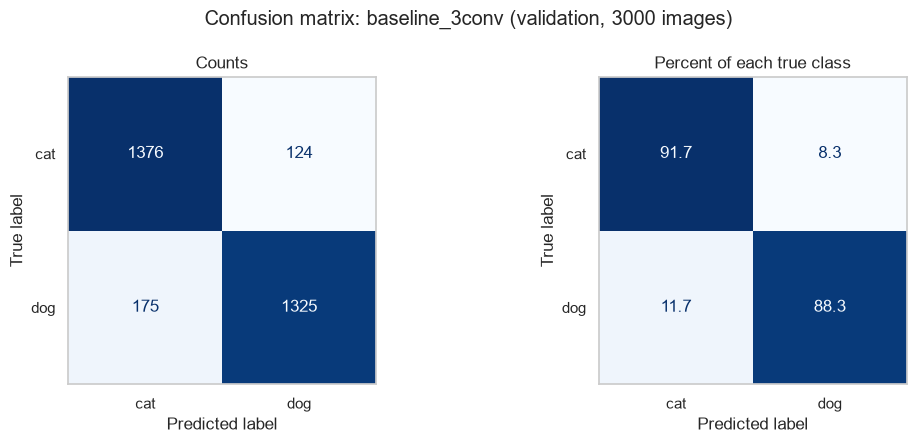

Cats correctly identified: 1376 / 1500  -> 124 cats mistaken for dogs
Dogs correctly identified: 1325 / 1500  -> 175 dogs mistaken for cats


In [60]:
cm = confusion_matrix(y_true, y_pred)                          # counts
cm_pct = confusion_matrix(y_true, y_pred, normalize="true")    # each row as a fraction of that class

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Counts")
ConfusionMatrixDisplay(cm_pct * 100, display_labels=CLASS_NAMES).plot(
    ax=axes[1], cmap="Blues", values_format=".1f", colorbar=False)
axes[1].set_title("Percent of each true class")

for ax in axes:
    ax.grid(False)          # remove the grid lines drawn over the matrix

fig.suptitle(f"Confusion matrix: {EVAL_RUN} (validation, {len(y_true)} images)")
plt.tight_layout()

FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / f"{EVAL_RUN}_confusion_matrix.png", dpi=150, bbox_inches="tight")   # for the report
plt.show()

tn, fp, fn, tp = cm.ravel()      # cat = 0, dog = 1
print(f"Cats correctly identified: {tn} / {tn + fp}  -> {fp} cats mistaken for dogs")
print(f"Dogs correctly identified: {tp} / {tp + fn}  -> {fn} dogs mistaken for cats")


<h1>Apply model on Test Dataset</h1>

In [61]:
from torch.utils.data import Dataset

class TestImages(Dataset):
    """Loads the unlabelled test images in id order and returns (image, id)."""
    def __init__(self, folder, transform):
        self.files = sorted(folder.glob("*.jpg"), key=lambda p: int(p.stem))   # 1, 2, ..., 500 in number order
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        path = self.files[i]
        with Image.open(path) as img:
            image = self.transform(img.convert("RGB"))
        return image, int(path.stem)            # the file name "37.jpg" becomes id 37

test_set = TestImages(DATA / "test", eval_transform)     # same fixed transform as validation
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Test images: {len(test_set)}")


Test images: 500


In [ ]:
ids, preds, dog_probs = [], [], []
best_model.eval()
with torch.no_grad():
    for images, image_ids in test_loader:
        outputs = best_model(images.to(device))
        preds.extend(outputs.argmax(dim=1).cpu().tolist())                   # 0 = cat, 1 = dog
        dog_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().tolist())
        ids.extend(image_ids.tolist())

# Fill the sample file's "label" column with our predictions, matching each row by id
sample = pd.read_csv(ROOT / "sampleSubmission.csv")          # template: ids 1..500 in the required order
pred_by_id = dict(zip(ids, preds))                            # {image id: predicted label}
sample["label"] = sample["id"].map(pred_by_id)                # look up our prediction for each id

assert sample["label"].notna().all(), "some ids have no prediction"
sample["label"] = sample["label"].astype(int)                 # make sure labels are 0/1 integers
sample.to_csv(ROOT / "submission.csv", index=False)          # save under the required name

# Keep the confidences too, for part (e)
test_results = pd.DataFrame({"id": ids, "label": preds, "p_dog": dog_probs}).sort_values("id")

print("submission.csv saved.")
print(sample["label"].map({0: "cat", 1: "dog"}).value_counts())
sample.head()



submission.csv saved.
label
dog    258
cat    242
Name: count, dtype: int64


,id,label
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1


<h1>Part F: Data Processing: No Data Augmentation</h1>

In [65]:
# The same 10,000 training images, but with the fixed validation-style transform (no augmentation)
noaug_train_set = Subset(datasets.ImageFolder(DATA / "train", transform=eval_transform), train_indices)

g_noaug = torch.Generator()
g_noaug.manual_seed(SEED)                     # same shuffle order as the main run
noaug_train_loader = DataLoader(noaug_train_set, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=4, pin_memory=True, persistent_workers=True,
                                generator=g_noaug)

# Quick check: without augmentation, the same image loaded twice should be identical
a, _ = noaug_train_set[0]
b, _ = noaug_train_set[0]
print("No randomness (no augmentation):", torch.equal(a, b))        # expect True
print(f"Training images: {len(noaug_train_set)}")                    # expect 10000


No randomness (no augmentation): True
Training images: 10000


In [66]:
def train_run(model, train_loader, run_name):
    """Train with the same settings as the main run. Saves the best model and the history. Returns the history."""
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    best_path = MODEL_DIR / f"{run_name}_best.pt"

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_val_acc, epochs_without_improvement = 0.0, 0

    for epoch in range(1, EPOCHS + 1):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        for key, value in [("train_loss", train_loss), ("train_acc", train_acc),
                           ("val_loss", val_loss), ("val_acc", val_acc), ("lr", current_lr)]:
            history[key].append(value)

        note = ""
        if val_acc > best_val_acc:
            best_val_acc, epochs_without_improvement = val_acc, 0
            torch.save(model.state_dict(), best_path)
            note = "  <- best so far, saved"
        else:
            epochs_without_improvement += 1

        print(f"Epoch {epoch:2d}/{EPOCHS} | train loss {train_loss:.4f}, acc {train_acc:.2%} | "
              f"val loss {val_loss:.4f}, acc {val_acc:.2%} | lr {current_lr:.1e} | {time.time() - start:.0f}s{note}")

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping: val accuracy hasn't improved for {PATIENCE} epochs.")
            break

    print(f"\nBest validation accuracy ({run_name}): {best_val_acc:.2%}")
    history_df = pd.DataFrame(history, index=range(1, len(history["train_loss"]) + 1))
    history_df.to_csv(MODEL_DIR / f"{run_name}_history.csv", index_label="epoch")
    return history_df


In [68]:
print(noaug_train_set.dataset.transform)

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
)


In [69]:
set_seed(SEED)                                   # same starting weights as the main run
noaug_model = CustomCNN().to(device)             # fresh, untrained model
noaug_history = train_run(noaug_model, noaug_train_loader, run_name="baseline_3conv_noaug")

Epoch  1/50 | train loss 0.7201, acc 55.70% | val loss 0.6809, acc 56.03% | lr 1.0e-03 | 50s  <- best so far, saved
Epoch  2/50 | train loss 0.6327, acc 65.52% | val loss 0.6527, acc 61.63% | lr 1.0e-03 | 20s  <- best so far, saved
Epoch  3/50 | train loss 0.5742, acc 70.94% | val loss 0.5543, acc 72.87% | lr 1.0e-03 | 20s  <- best so far, saved
Epoch  4/50 | train loss 0.5171, acc 75.01% | val loss 0.5339, acc 72.87% | lr 1.0e-03 | 20s
Epoch  5/50 | train loss 0.4526, acc 79.02% | val loss 0.5440, acc 75.77% | lr 1.0e-03 | 20s  <- best so far, saved
Epoch  6/50 | train loss 0.3947, acc 82.25% | val loss 0.5029, acc 77.30% | lr 1.0e-03 | 20s  <- best so far, saved
Epoch  7/50 | train loss 0.3256, acc 85.51% | val loss 0.5882, acc 76.40% | lr 1.0e-03 | 20s
Epoch  8/50 | train loss 0.2624, acc 88.84% | val loss 0.6067, acc 77.53% | lr 1.0e-03 | 20s  <- best so far, saved
Epoch  9/50 | train loss 0.2167, acc 91.15% | val loss 0.5815, acc 76.67% | lr 5.0e-04 | 20s
Epoch 10/50 | train loss 

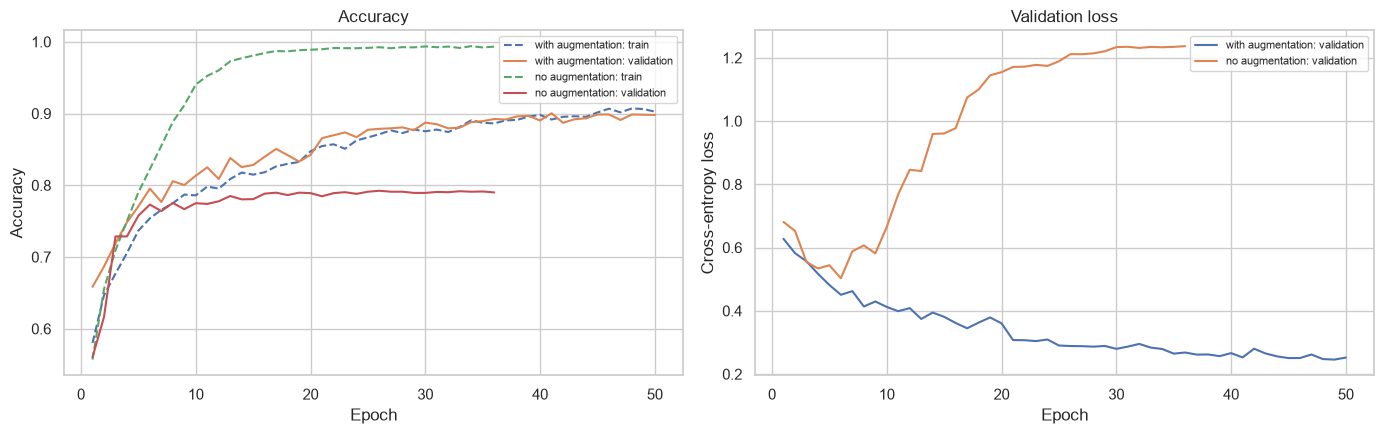

,run,best val acc,best epoch,train acc at best epoch,epochs trained
0,with augmentation,90.03%,41,89.16%,50
1,no augmentation,79.23%,26,99.24%,36


In [70]:
runs = {"with augmentation": "baseline_3conv", "no augmentation": "baseline_3conv_noaug"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
rows = []
for label, run in runs.items():
    h = pd.read_csv(MODEL_DIR / f"{run}_history.csv", index_col="epoch")
    axes[0].plot(h.index, h["train_acc"], "--", label=f"{label}: train")
    axes[0].plot(h.index, h["val_acc"], label=f"{label}: validation")
    axes[1].plot(h.index, h["val_loss"], label=f"{label}: validation")
    best_epoch = h["val_acc"].idxmax()
    rows.append({"run": label,
                 "best val acc": f"{h['val_acc'].max():.2%}",
                 "best epoch": best_epoch,
                 "train acc at best epoch": f"{h.loc[best_epoch, 'train_acc']:.2%}",
                 "epochs trained": len(h)})

axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].set(title="Validation loss", xlabel="Epoch", ylabel="Cross-entropy loss")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / "augmentation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(rows)


<h1>Part G: Cifar-10 dataset</h1>

In [28]:
from torchvision.datasets import CIFAR10

# Your local copy: CIFAR10 looks for the "cifar-10-batches-py" folder inside this folder
CIFAR_DIR = ROOT / "cifar-10-python"
CIFAR_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                 "dog", "frog", "horse", "ship", "truck"]

cifar_train_raw = CIFAR10(CIFAR_DIR, train=True, download=False)    # the 5 data_batch files
cifar_test_raw = CIFAR10(CIFAR_DIR, train=False, download=False)    # test_batch

print(f"Training images: {len(cifar_train_raw)}, test images: {len(cifar_test_raw)}")
print("Image size:", cifar_train_raw.data.shape[1:], "(height, width, channels)")
print("Classes:", cifar_train_raw.classes)


Training images: 50000, test images: 10000
Image size: (32, 32, 3) (height, width, channels)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


,train,test
airplane,5000,1000
automobile,5000,1000
bird,5000,1000
cat,5000,1000
deer,5000,1000
dog,5000,1000
frog,5000,1000
horse,5000,1000
ship,5000,1000
truck,5000,1000


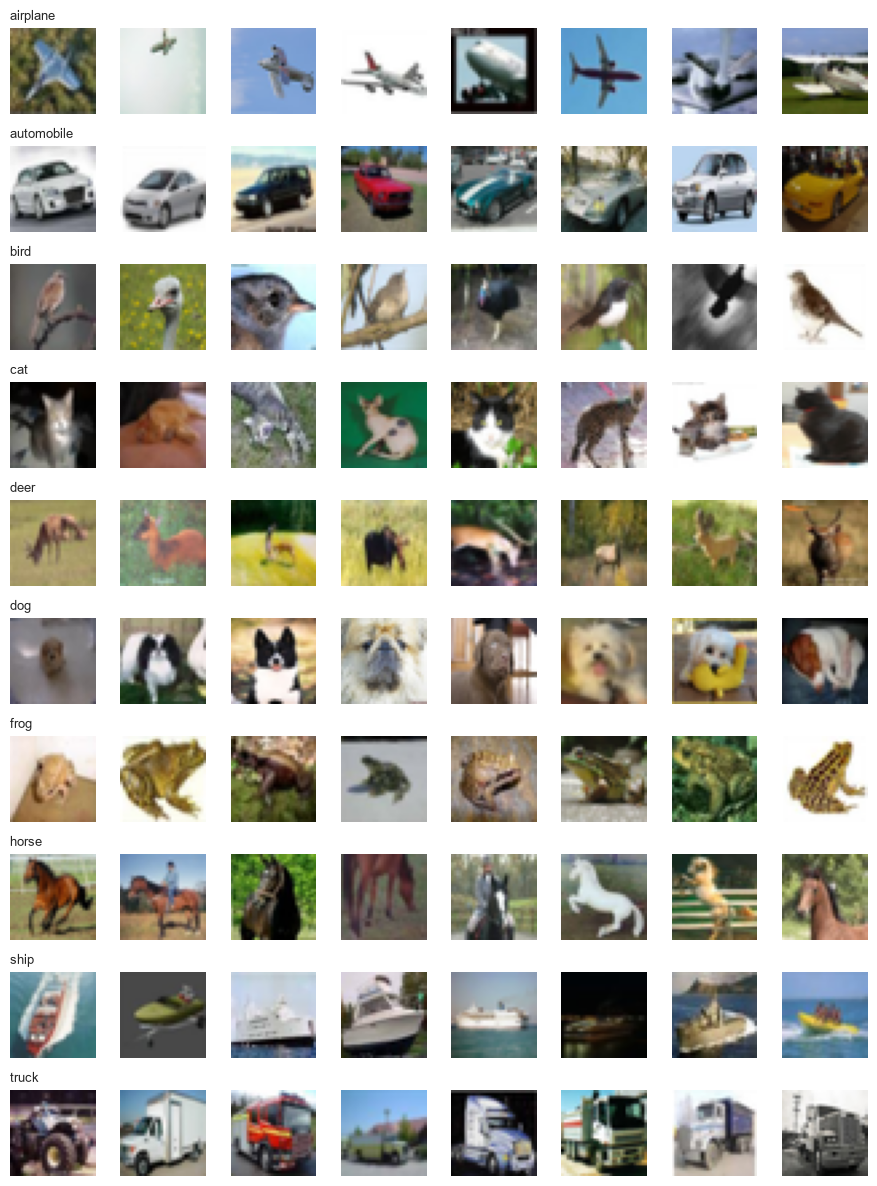

In [29]:
# Images per class: training vs test
train_counts = pd.Series(cifar_train_raw.targets).value_counts().sort_index()
test_counts = pd.Series(cifar_test_raw.targets).value_counts().sort_index()
display(pd.DataFrame({"train": train_counts.values, "test": test_counts.values}, index=CIFAR_CLASSES))

# 8 random examples of each class
rng = np.random.default_rng(SEED)
targets = np.array(cifar_train_raw.targets)
fig, axes = plt.subplots(10, 8, figsize=(9, 12))
for row, class_name in enumerate(CIFAR_CLASSES):
    picks = rng.choice(np.where(targets == row)[0], size=8, replace=False)
    for col, idx in enumerate(picks):
        axes[row, col].imshow(cifar_train_raw.data[idx])
        axes[row, col].axis("off")
    axes[row, 0].set_title(class_name, fontsize=9, loc="left")
plt.tight_layout()
plt.show()


,train,test
class,,
airplane,5000,1000
automobile,5000,1000
bird,5000,1000
cat,5000,1000
deer,5000,1000
dog,5000,1000
frog,5000,1000
horse,5000,1000
ship,5000,1000


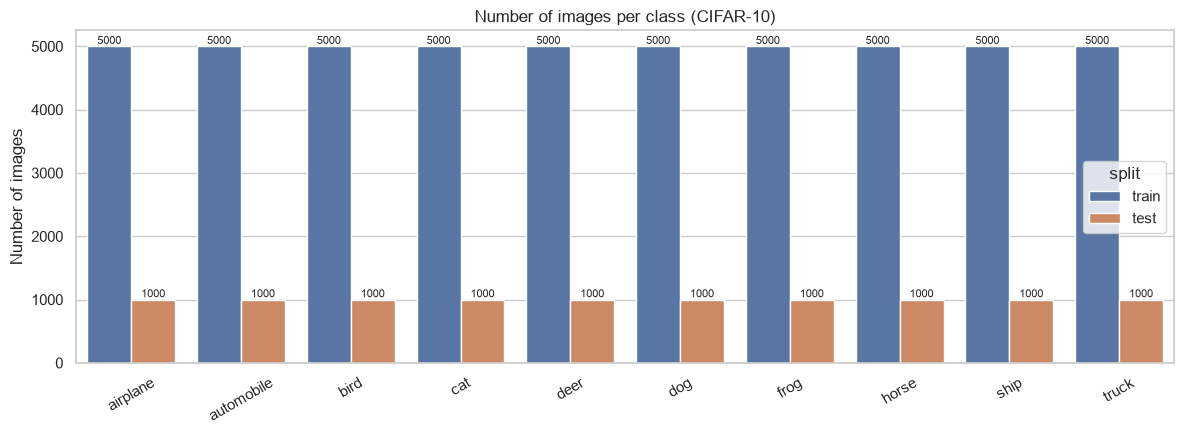

In [30]:
train_counts = pd.Series(cifar_train_raw.targets).value_counts().sort_index()   # label 0..9 -> count
test_counts = pd.Series(cifar_test_raw.targets).value_counts().sort_index()

count_df = pd.DataFrame({"class": CIFAR_CLASSES,
                         "train": train_counts.values,
                         "test": test_counts.values})
display(count_df.set_index("class"))

# "Long" format so seaborn can draw a train bar and a test bar for each class
count_long = count_df.melt(id_vars="class", var_name="split", value_name="images")

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.barplot(data=count_long, x="class", y="images", hue="split", order=CIFAR_CLASSES, ax=ax)
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8)            # write the count on top of each bar
ax.set(title="Number of images per class (CIFAR-10)", xlabel="", ylabel="Number of images")
plt.xticks(rotation=30)
plt.tight_layout()

FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / "cifar_class_counts.png", dpi=150, bbox_inches="tight")
plt.show()


In [31]:
# 1. Hold out 500 training images per class (5,000 in total) as a validation set.
#    The 10,000 test images are used only once, at the very end.
def split_per_class(targets, n_val_per_class, seed):
    rng = np.random.default_rng(seed)
    targets = np.array(targets)
    val_idx = []
    for c in range(10):
        val_idx.extend(rng.choice(np.where(targets == c)[0], size=n_val_per_class, replace=False).tolist())
    val_lookup = set(val_idx)
    train_idx = [i for i in range(len(targets)) if i not in val_lookup]
    return sorted(train_idx), sorted(val_idx)

cifar_train_idx, cifar_val_idx = split_per_class(cifar_train_raw.targets, 500, SEED)
print(f"CIFAR train: {len(cifar_train_idx)}, validation: {len(cifar_val_idx)}, test: {len(cifar_test_raw)}")

# 2. Normalisation statistics from the 45,000 TRAINING images only (never validation or test)
train_pixels = cifar_train_raw.data[cifar_train_idx]          # (45000, 32, 32, 3), values 0-255
CIFAR_MEAN = [float(train_pixels[..., c].mean() / 255) for c in range(3)]
CIFAR_STD = [float(train_pixels[..., c].std() / 255) for c in range(3)]
print("CIFAR mean (R, G, B):", [round(m, 4) for m in CIFAR_MEAN])
print("CIFAR std  (R, G, B):", [round(s, 4) for s in CIFAR_STD])

# 3. Transforms. The final steps are SHARED, so training and evaluation can never differ (lesson learned!)
#cifar_final_steps = [transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)]
cifar_final_steps = [transforms.ToTensor()]
cifar_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),   # shift the image by up to 4 pixels
    transforms.RandomHorizontalFlip(),                               # mirror left-right (50%)
    *cifar_final_steps,
])
cifar_eval_transform = transforms.Compose(cifar_final_steps)        # already 32x32, so no resize or crop

# 4. Datasets and loaders
cifar_train_set = Subset(CIFAR10(CIFAR_DIR, train=True, transform=cifar_train_transform), cifar_train_idx)
cifar_val_set = Subset(CIFAR10(CIFAR_DIR, train=True, transform=cifar_eval_transform), cifar_val_idx)
cifar_test_set = CIFAR10(CIFAR_DIR, train=False, transform=cifar_eval_transform)

CIFAR_BATCH = 32
g_cifar = torch.Generator()
g_cifar.manual_seed(SEED)
cifar_train_loader = DataLoader(cifar_train_set, batch_size=CIFAR_BATCH, shuffle=True, num_workers=2,
                                pin_memory=True, persistent_workers=True, generator=g_cifar)
cifar_val_loader = DataLoader(cifar_val_set, batch_size=256, shuffle=False, num_workers=2,
                              pin_memory=True, persistent_workers=True)
cifar_test_loader = DataLoader(cifar_test_set, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# 5. Safety check: training and validation batches on the same scale
xb, _ = next(iter(cifar_train_loader))
xv, _ = next(iter(cifar_val_loader))
print(f"train batch {tuple(xb.shape)}, pixels {xb.min():.2f} to {xb.max():.2f}")
print(f"val batch   {tuple(xv.shape)}, pixels {xv.min():.2f} to {xv.max():.2f}")


CIFAR train: 45000, validation: 5000, test: 10000
CIFAR mean (R, G, B): [0.4913, 0.4821, 0.4465]
CIFAR std  (R, G, B): [0.2472, 0.2436, 0.2617]
train batch (32, 3, 32, 32), pixels 0.00 to 1.00
val batch   (256, 3, 32, 32), pixels 0.00 to 1.00


In [32]:
class CifarCNN(nn.Module):
    """Our Dogs-vs-Cats CNN adapted to CIFAR-10: 32x32 input, 'same' padding, 10 outputs."""
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   nn.ReLU(inplace=True), nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  nn.ReLU(inplace=True), nn.MaxPool2d(2),  # 16 -> 8
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),  # 8  -> 4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                          # 128 x 4 x 4 -> 2,048
            nn.Linear(128 * 4 * 4, 128),           # hidden dense layer
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),           # 10 scores, one per class
        )
        self._init_weights()

    def _init_weights(self):
        """Same as the Dogs-vs-Cats CNN: Kaiming for ReLU layers, small random output layer."""
        output_layer = self.classifier[-1]
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                if m is output_layer:
                    nn.init.normal_(m.weight, mean=0, std=0.01)
                else:
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))

# Shape check
set_seed(SEED)
cifar_model = CifarCNN().to(device)
x = torch.randn(2, 3, 32, 32, device=device)
for i, layer in enumerate(cifar_model.features, start=1):
    x = layer(x)
    print(f"layer {i} ({layer.__class__.__name__}): {tuple(x.shape)}")
print("final output:", tuple(cifar_model(torch.randn(2, 3, 32, 32, device=device)).shape))   # expect (2, 10)
print(f"Trainable parameters: {sum(p.numel() for p in cifar_model.parameters()):,}")           # expect 356,810


layer 1 (Conv2d): (2, 32, 32, 32)
layer 2 (ReLU): (2, 32, 32, 32)
layer 3 (MaxPool2d): (2, 32, 16, 16)
layer 4 (Conv2d): (2, 64, 16, 16)
layer 5 (ReLU): (2, 64, 16, 16)
layer 6 (MaxPool2d): (2, 64, 8, 8)
layer 7 (Conv2d): (2, 128, 8, 8)
layer 8 (ReLU): (2, 128, 8, 8)
layer 9 (MaxPool2d): (2, 128, 4, 4)
final output: (2, 10)
Trainable parameters: 356,810


In [33]:
def train_model(model, train_loader, val_loader, run_name, lr=LEARNING_RATE, epochs=EPOCHS):
    """Train a model and check it on val_loader after every epoch.
    Saves the best model (by validation accuracy) and the history. Returns the history as a table."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    # If validation loss doesn't improve for 2 epochs, halve the learning rate
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    best_path = MODEL_DIR / f"{run_name}_best.pt"

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_val_acc = 0.0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer)   # learn
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)                           # check
        scheduler.step(val_loss)                                                           # maybe lower the learning rate
        current_lr = optimizer.param_groups[0]["lr"]

        # record this epoch's results
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # save the model whenever validation accuracy reaches a new best
        note = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_path)
            note = "  <- best so far, saved"
        else:
            epochs_without_improvement += 1

        print(f"Epoch {epoch:3d}/{epochs} | train loss {train_loss:.4f}, acc {train_acc:.2%} | "
              f"val loss {val_loss:.4f}, acc {val_acc:.2%} | lr {current_lr:.1e} | "
              f"{time.time() - start:.0f}s{note}")

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping: val accuracy hasn't improved for {PATIENCE} epochs.")
            break

    print(f"\nBest validation accuracy ({run_name}): {best_val_acc:.2%}")
    history_df = pd.DataFrame(history, index=range(1, len(history["train_loss"]) + 1))
    history_df.to_csv(MODEL_DIR / f"{run_name}_history.csv", index_label="epoch")
    return history_df


In [81]:
CIFAR_RUN = "cifar_cnn_100ep"                    # new name: keeps the 50-epoch run's files

# Fresh, seeded training loader right before training
g_cifar = torch.Generator()
g_cifar.manual_seed(SEED)
cifar_train_loader = DataLoader(cifar_train_set, batch_size=CIFAR_BATCH, shuffle=True, num_workers=2,
                                pin_memory=True, persistent_workers=True, generator=g_cifar)

set_seed(SEED)                                   # same starting weights as before
cifar_model = CifarCNN().to(device)              # fresh, untrained model
cifar_history = train_model(cifar_model, cifar_train_loader, cifar_val_loader,
                            run_name=CIFAR_RUN, epochs=100)


Epoch   1/100 | train loss 1.7224, acc 35.43% | val loss 1.3346, acc 51.64% | lr 1.0e-03 | 19s  <- best so far, saved
Epoch   2/100 | train loss 1.4024, acc 49.22% | val loss 1.1641, acc 57.86% | lr 1.0e-03 | 21s  <- best so far, saved
Epoch   3/100 | train loss 1.2413, acc 55.86% | val loss 0.9795, acc 65.00% | lr 1.0e-03 | 16s  <- best so far, saved
Epoch   4/100 | train loss 1.1342, acc 60.04% | val loss 0.9107, acc 67.86% | lr 1.0e-03 | 30s  <- best so far, saved
Epoch   5/100 | train loss 1.0564, acc 63.19% | val loss 0.8765, acc 68.96% | lr 1.0e-03 | 39s  <- best so far, saved
Epoch   6/100 | train loss 1.0077, acc 65.00% | val loss 0.8298, acc 70.38% | lr 1.0e-03 | 10s  <- best so far, saved
Epoch   7/100 | train loss 0.9628, acc 66.71% | val loss 0.8026, acc 71.66% | lr 1.0e-03 | 10s  <- best so far, saved
Epoch   8/100 | train loss 0.9330, acc 67.64% | val loss 0.7489, acc 73.78% | lr 1.0e-03 | 11s  <- best so far, saved
Epoch   9/100 | train loss 0.8920, acc 69.04% | val loss

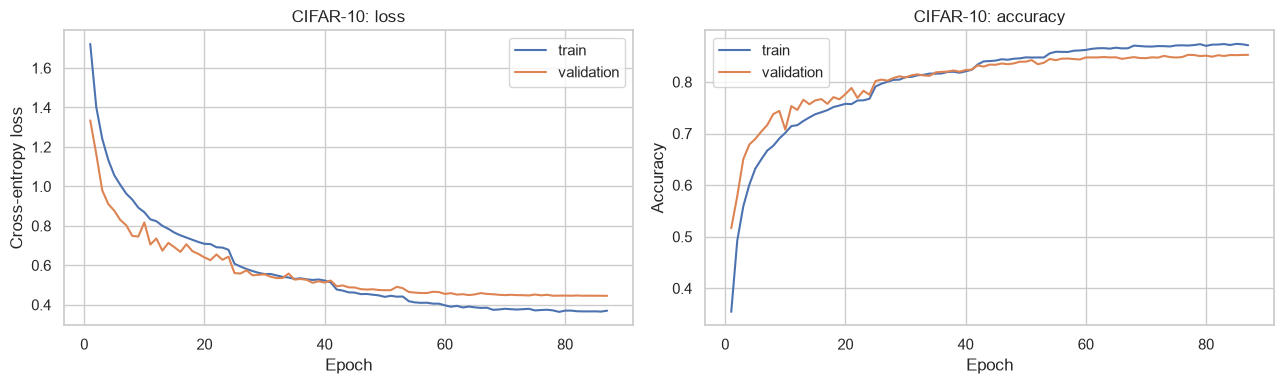

CIFAR-10 TEST accuracy: 85.04% on 10000 images

              precision    recall  f1-score   support

    airplane     0.8482    0.8940    0.8705      1000
  automobile     0.9187    0.9490    0.9336      1000
        bird     0.8277    0.7590    0.7919      1000
         cat     0.7265    0.6880    0.7067      1000
        deer     0.8481    0.8320    0.8400      1000
         dog     0.7605    0.7940    0.7769      1000
        frog     0.8575    0.9030    0.8797      1000
       horse     0.8629    0.8810    0.8718      1000
        ship     0.9393    0.8970    0.9176      1000
       truck     0.9116    0.9070    0.9093      1000

    accuracy                         0.8504     10000
   macro avg     0.8501    0.8504    0.8498     10000
weighted avg     0.8501    0.8504    0.8498     10000



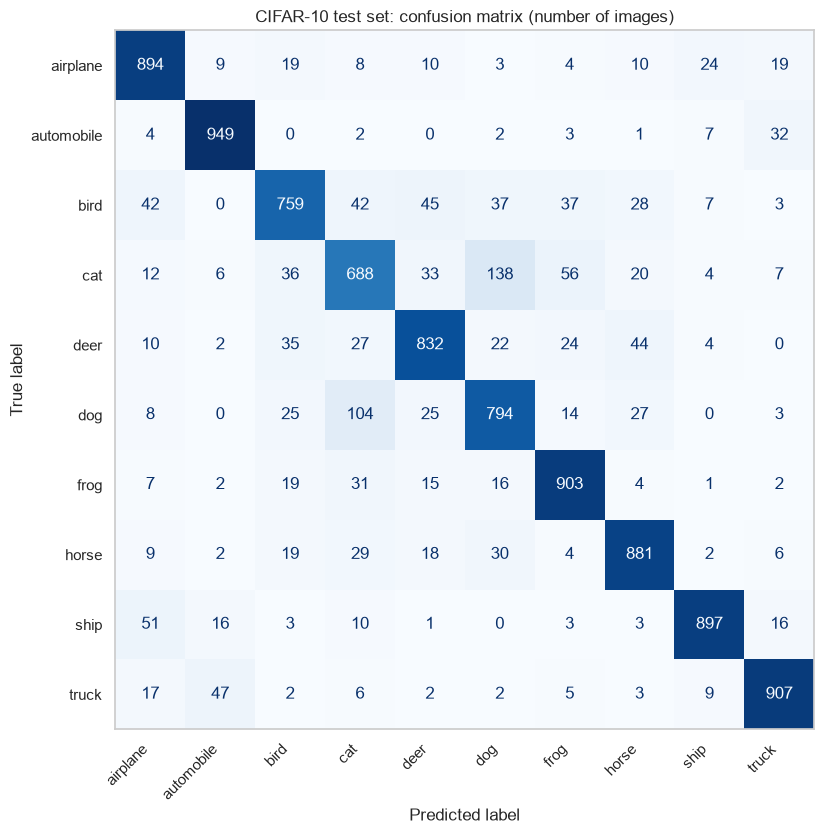

  airplane:  894 / 1000 correct
automobile:  949 / 1000 correct
      bird:  759 / 1000 correct
       cat:  688 / 1000 correct
      deer:  832 / 1000 correct
       dog:  794 / 1000 correct
      frog:  903 / 1000 correct
     horse:  881 / 1000 correct
      ship:  897 / 1000 correct
     truck:  907 / 1000 correct


In [82]:
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 1. Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(cifar_history.index, cifar_history["train_loss"], label="train")
axes[0].plot(cifar_history.index, cifar_history["val_loss"], label="validation")
axes[0].set(title="CIFAR-10: loss", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[1].plot(cifar_history.index, cifar_history["train_acc"], label="train")
axes[1].plot(cifar_history.index, cifar_history["val_acc"], label="validation")
axes[1].set(title="CIFAR-10: accuracy", xlabel="Epoch", ylabel="Accuracy")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / f"{CIFAR_RUN}_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Load the BEST checkpoint and evaluate ONCE on the 10,000 test images
best_cifar = CifarCNN().to(device)
best_cifar.load_state_dict(torch.load(MODEL_DIR / f"{CIFAR_RUN}_best.pt", map_location=device))
y_true_c, y_pred_c, _ = get_predictions(best_cifar, cifar_test_loader)   # 3rd output not needed here

print(f"CIFAR-10 TEST accuracy: {accuracy_score(y_true_c, y_pred_c):.2%} on {len(y_true_c)} images\n")
print(classification_report(y_true_c, y_pred_c, target_names=CIFAR_CLASSES, digits=4))

# 3. 10 x 10 confusion matrix with COUNTS (each true class has 1,000 test images)
cm_c = confusion_matrix(y_true_c, y_pred_c)
fig, ax = plt.subplots(figsize=(10, 8.5))
ConfusionMatrixDisplay(cm_c, display_labels=CIFAR_CLASSES).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False)       # "d" = whole numbers
ax.grid(False)                                                   # no grid lines over the numbers
ax.set_title("CIFAR-10 test set: confusion matrix (number of images)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / f"{CIFAR_RUN}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Correct predictions per class, out of 1,000 each
correct_per_class = cm_c.diagonal()                              # the diagonal = correct predictions
for name, correct, total in zip(CIFAR_CLASSES, correct_per_class, cm_c.sum(axis=1)):
    print(f"{name:>10}: {correct:4d} / {total} correct")


<h1>Part H: Imbalanced CIFAR-10</h1>

,training images
airplane,4500
automobile,4500
bird,450
cat,450
deer,4500
dog,4500
frog,4500
horse,4500
ship,4500
truck,450


Imbalanced training set: 32850 images (balanced version had 45000)
Imbalance ratio (largest / smallest class): 10 : 1


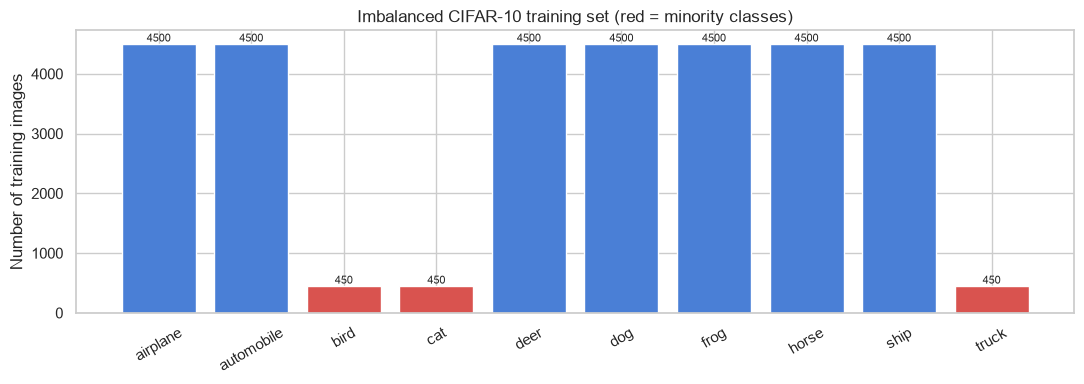

In [34]:
MINORITY_CLASSES = ["bird", "cat", "truck"]    # these classes get far fewer training images
KEEP_FRACTION = 0.10                           # keep only 10% of their images (450 of 4,500)

all_targets = np.array(cifar_train_raw.targets)
train_idx_arr = np.array(cifar_train_idx)               # our 45,000-image training split from G3
minority_ids = [CIFAR_CLASSES.index(name) for name in MINORITY_CLASSES]

rng = np.random.default_rng(SEED)
imb_idx = []
for c in range(10):
    class_idx = train_idx_arr[all_targets[train_idx_arr] == c]          # this class's training images
    if c in minority_ids:
        class_idx = rng.choice(class_idx, size=int(len(class_idx) * KEEP_FRACTION), replace=False)
    imb_idx.extend(class_idx.tolist())
imb_idx = sorted(imb_idx)

imb_labels = all_targets[imb_idx]                        # label of each image, in the same order
imb_counts = np.bincount(imb_labels, minlength=10)       # images per class
display(pd.DataFrame({"training images": imb_counts}, index=CIFAR_CLASSES))
print(f"Imbalanced training set: {len(imb_idx)} images (balanced version had {len(cifar_train_idx)})")
print(f"Imbalance ratio (largest / smallest class): {imb_counts.max() / imb_counts.min():.0f} : 1")

# Same augmentation as part (g); validation and test stay balanced and unchanged
imb_train_set = Subset(CIFAR10(CIFAR_DIR, train=True, transform=cifar_train_transform), imb_idx)

# Bar chart (red = minority classes)
fig, ax = plt.subplots(figsize=(11, 4))
colours = ["#d9534f" if name in MINORITY_CLASSES else "#4a7fd6" for name in CIFAR_CLASSES]
bars = ax.bar(CIFAR_CLASSES, imb_counts, color=colours)
ax.bar_label(bars, fontsize=8)
ax.set(title="Imbalanced CIFAR-10 training set (red = minority classes)", ylabel="Number of training images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "cifar_imbalanced_counts.png", dpi=150, bbox_inches="tight")
plt.show()


In [35]:
def train_model(model, train_loader, val_loader, run_name, lr=LEARNING_RATE, epochs=EPOCHS,
                train_loss_fn=None):
    """Train a model and check it on val_loader after every epoch.
    train_loss_fn: loss used for LEARNING (default: normal cross-entropy). Validation always uses the normal loss.
    Saves the best model (by validation accuracy) and the history. Returns the history as a table."""
    if train_loss_fn is None:
        train_loss_fn = loss_fn                       # normal (unweighted) cross-entropy
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    best_path = MODEL_DIR / f"{run_name}_best.pt"

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_val_acc = 0.0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, train_loss_fn, optimizer)   # learn
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)                                 # check (normal loss)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        note = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_path)
            note = "  <- best so far, saved"
        else:
            epochs_without_improvement += 1

        print(f"Epoch {epoch:3d}/{epochs} | train loss {train_loss:.4f}, acc {train_acc:.2%} | "
              f"val loss {val_loss:.4f}, acc {val_acc:.2%} | lr {current_lr:.1e} | "
              f"{time.time() - start:.0f}s{note}")

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping: val accuracy hasn't improved for {PATIENCE} epochs.")
            break

    print(f"\nBest validation accuracy ({run_name}): {best_val_acc:.2%}")
    history_df = pd.DataFrame(history, index=range(1, len(history["train_loss"]) + 1))
    history_df.to_csv(MODEL_DIR / f"{run_name}_history.csv", index_label="epoch")
    return history_df


In [36]:
from torch.utils.data import WeightedRandomSampler

def make_imb_loader(oversample=False):
    """Fresh, seeded training loader for the imbalanced set.
    oversample=True picks rare-class images more often, so each batch is roughly balanced."""
    g = torch.Generator()
    g.manual_seed(SEED)
    if oversample:
        sample_weights = 1.0 / imb_counts[imb_labels]       # each image's weight = 1 / (size of its class)
        sampler = WeightedRandomSampler(torch.as_tensor(sample_weights, dtype=torch.double),
                                        num_samples=len(imb_labels),   # same number of images per epoch
                                        replacement=True, generator=g)
        return DataLoader(imb_train_set, batch_size=CIFAR_BATCH, sampler=sampler, num_workers=2,
                          pin_memory=True, persistent_workers=True, generator=g)
    return DataLoader(imb_train_set, batch_size=CIFAR_BATCH, shuffle=True, num_workers=2,
                      pin_memory=True, persistent_workers=True, generator=g)

# Run 1: baseline, plain cross-entropy, no imbalance fix
set_seed(SEED)
imb_baseline = CifarCNN().to(device)
hist_imb_base = train_model(imb_baseline, make_imb_loader(), cifar_val_loader,
                            run_name="cifar_imb_baseline", epochs=100)


Epoch   1/100 | train loss 1.5245, acc 44.21% | val loss 1.8344, acc 43.92% | lr 1.0e-03 | 19s  <- best so far, saved
Epoch   2/100 | train loss 1.1862, acc 59.33% | val loss 1.5299, acc 50.70% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   3/100 | train loss 1.0268, acc 65.74% | val loss 1.5328, acc 53.38% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   4/100 | train loss 0.9340, acc 69.39% | val loss 1.3806, acc 54.84% | lr 1.0e-03 | 8s  <- best so far, saved
Epoch   5/100 | train loss 0.8690, acc 71.56% | val loss 1.3483, acc 56.40% | lr 1.0e-03 | 8s  <- best so far, saved
Epoch   6/100 | train loss 0.8161, acc 73.32% | val loss 1.3731, acc 57.30% | lr 1.0e-03 | 6s  <- best so far, saved
Epoch   7/100 | train loss 0.7742, acc 74.85% | val loss 1.3304, acc 57.94% | lr 1.0e-03 | 6s  <- best so far, saved
Epoch   8/100 | train loss 0.7477, acc 75.72% | val loss 1.2054, acc 60.12% | lr 1.0e-03 | 6s  <- best so far, saved
Epoch   9/100 | train loss 0.7113, acc 77.13% | val loss 1.1976

In [37]:
# Weight for each class = total images / (10 x images in that class): rare classes get bigger weights
class_weights = len(imb_labels) / (10 * imb_counts)
print("Class weights:", dict(zip(CIFAR_CLASSES, class_weights.round(2))))   # about 0.73 (common), 7.3 (rare)

weighted_loss = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))

set_seed(SEED)
imb_weighted = CifarCNN().to(device)
hist_imb_weighted = train_model(imb_weighted, make_imb_loader(), cifar_val_loader,
                                run_name="cifar_imb_weighted", epochs=100, train_loss_fn=weighted_loss)


Class weights: {'airplane': np.float64(0.73), 'automobile': np.float64(0.73), 'bird': np.float64(7.3), 'cat': np.float64(7.3), 'deer': np.float64(0.73), 'dog': np.float64(0.73), 'frog': np.float64(0.73), 'horse': np.float64(0.73), 'ship': np.float64(0.73), 'truck': np.float64(7.3)}
Epoch   1/100 | train loss 1.8951, acc 35.85% | val loss 1.5938, acc 39.98% | lr 1.0e-03 | 17s  <- best so far, saved
Epoch   2/100 | train loss 1.5831, acc 48.29% | val loss 1.4157, acc 48.68% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   3/100 | train loss 1.4407, acc 53.84% | val loss 1.3218, acc 51.02% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   4/100 | train loss 1.3514, acc 56.61% | val loss 1.2768, acc 53.82% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   5/100 | train loss 1.2630, acc 60.02% | val loss 1.1200, acc 59.52% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   6/100 | train loss 1.2076, acc 62.01% | val loss 1.1138, acc 59.44% | lr 1.0e-03 | 7s
Epoch   7/100 | train loss 1.1572, ac

In [38]:
set_seed(SEED)
imb_oversample = CifarCNN().to(device)
hist_imb_over = train_model(imb_oversample, make_imb_loader(oversample=True), cifar_val_loader,
                            run_name="cifar_imb_oversample", epochs=100)

Epoch   1/100 | train loss 1.7967, acc 32.60% | val loss 1.4700, acc 47.42% | lr 1.0e-03 | 15s  <- best so far, saved
Epoch   2/100 | train loss 1.4908, acc 45.56% | val loss 1.2193, acc 55.84% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   3/100 | train loss 1.3231, acc 52.31% | val loss 1.0988, acc 60.70% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   4/100 | train loss 1.1908, acc 57.74% | val loss 1.0964, acc 60.82% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   5/100 | train loss 1.1029, acc 60.83% | val loss 0.9881, acc 64.62% | lr 1.0e-03 | 8s  <- best so far, saved
Epoch   6/100 | train loss 1.0310, acc 63.73% | val loss 0.9363, acc 67.18% | lr 1.0e-03 | 10s  <- best so far, saved
Epoch   7/100 | train loss 0.9580, acc 66.79% | val loss 0.9007, acc 68.54% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   8/100 | train loss 0.9143, acc 68.26% | val loss 0.8592, acc 70.50% | lr 1.0e-03 | 7s  <- best so far, saved
Epoch   9/100 | train loss 0.8707, acc 69.91% | val loss 0.845

In [41]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

@torch.no_grad()
def get_predictions(model, loader):
    """Return true labels, predicted labels and P(class 1) for every image in the loader."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for images, labels in loader:
        outputs = model(images.to(device))
        probs = torch.softmax(outputs, dim=1)              # scores -> probabilities
        all_labels.extend(labels.tolist())
        all_preds.extend(outputs.argmax(dim=1).cpu().tolist())
        all_probs.extend(probs[:, 1].cpu().tolist())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


,validation accuracy,test accuracy,macro F1 (test),minority recall (avg of 3),majority recall (avg of 7)
method,,,,,
balanced data (part g),85.26%,85.04%,0.8498,78.47%,87.86%
imbalanced: baseline,71.48%,72.33%,0.6768,28.67%,91.04%
imbalanced: class-weighted loss,77.00%,76.63%,0.7604,59.30%,84.06%
imbalanced: oversampling,76.66%,76.96%,0.7626,56.80%,85.60%


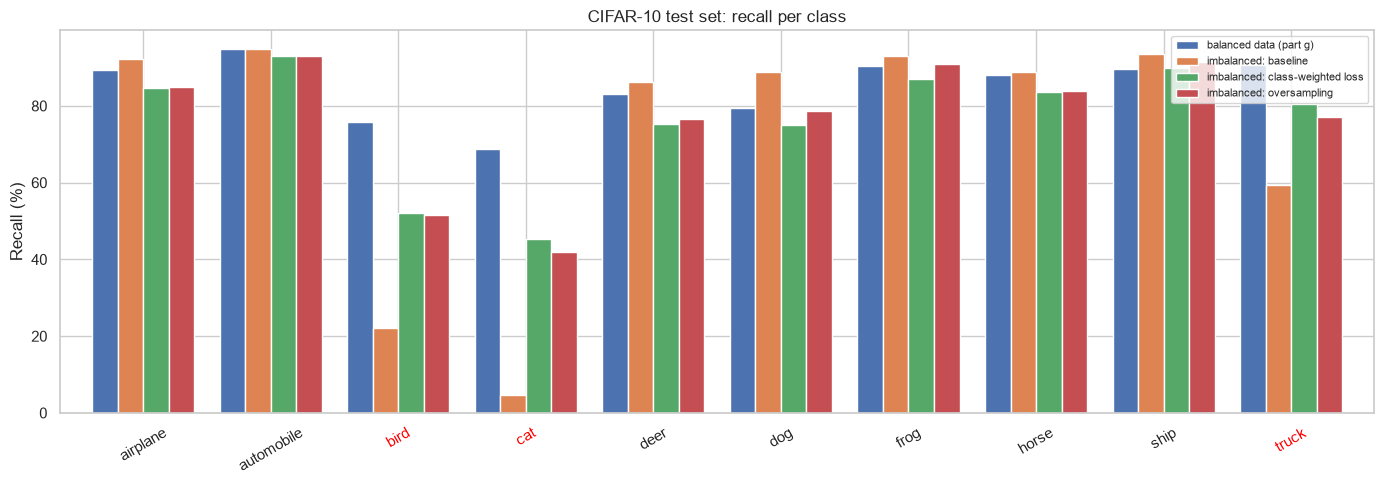

,balanced data (part g),imbalanced: baseline,imbalanced: class-weighted loss,imbalanced: oversampling
airplane,89.4,92.1,84.6,84.8
automobile,94.9,94.9,92.9,92.9
bird,75.9,22.0,52.2,51.5
cat,68.8,4.7,45.3,41.8
deer,83.2,86.3,75.4,76.6
dog,79.4,88.8,75.0,78.6
frog,90.3,92.9,87.0,90.9
horse,88.1,88.9,83.6,83.9
ship,89.7,93.4,89.9,91.5
truck,90.7,59.3,80.4,77.1


In [43]:
from sklearn.metrics import recall_score, f1_score

runs = {"balanced data (part g)": "cifar_cnn_100ep",       # reference: no imbalance
        "imbalanced: baseline": "cifar_imb_baseline",
        "imbalanced: class-weighted loss": "cifar_imb_weighted",
        "imbalanced: oversampling": "cifar_imb_oversample"}

rows, recalls = [], {}
for label, run in runs.items():
    m = CifarCNN().to(device)
    m.load_state_dict(torch.load(MODEL_DIR / f"{run}_best.pt", map_location=device))

    y_v, y_vp, _ = get_predictions(m, cifar_val_loader)     # validation set (5,000 images)
    y_t, y_p, _ = get_predictions(m, cifar_test_loader)     # test set (10,000 images)

    per_class_recall = recall_score(y_t, y_p, average=None)      # % of each true class found (test)
    recalls[label] = per_class_recall
    rows.append({"method": label,
                 "validation accuracy": f"{accuracy_score(y_v, y_vp):.2%}",
                 "test accuracy": f"{accuracy_score(y_t, y_p):.2%}",
                 "macro F1 (test)": f"{f1_score(y_t, y_p, average='macro'):.4f}",
                 "minority recall (avg of 3)": f"{per_class_recall[minority_ids].mean():.2%}",
                 "majority recall (avg of 7)": f"{np.delete(per_class_recall, minority_ids).mean():.2%}"})
display(pd.DataFrame(rows).set_index("method"))

# Per-class recall chart on the test set (minority class names in red)
recall_df = pd.DataFrame(recalls, index=CIFAR_CLASSES) * 100
ax = recall_df.plot(kind="bar", figsize=(14, 5), rot=30, width=0.8)
ax.set(title="CIFAR-10 test set: recall per class", ylabel="Recall (%)", xlabel="")
for tick in ax.get_xticklabels():
    if tick.get_text() in MINORITY_CLASSES:
        tick.set_color("red")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "cifar_imbalance_recall.png", dpi=150, bbox_inches="tight")
plt.show()
display(recall_df.round(1))

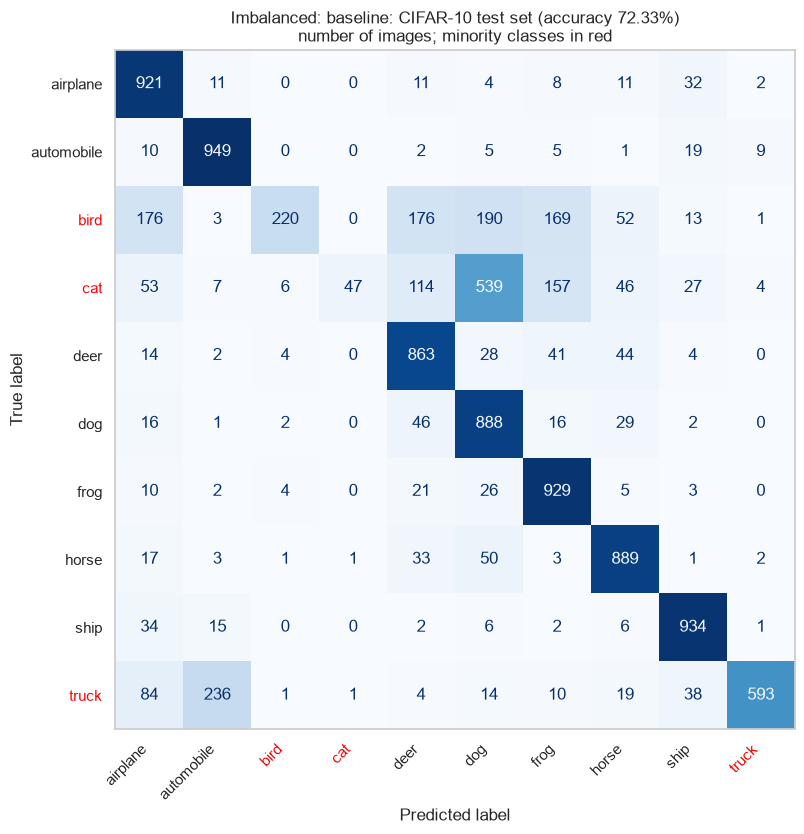

  bird: 220 / 1000 correct; most often mistaken for dog (190 images)
   cat: 47 / 1000 correct; most often mistaken for dog (539 images)
 truck: 593 / 1000 correct; most often mistaken for automobile (236 images)



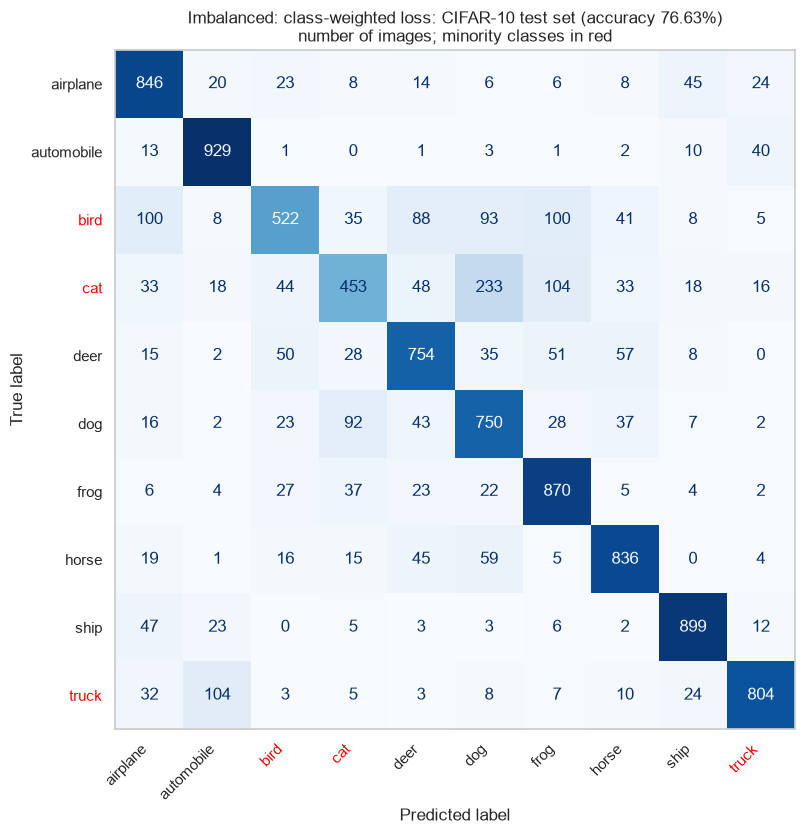

  bird: 522 / 1000 correct; most often mistaken for airplane (100 images)
   cat: 453 / 1000 correct; most often mistaken for dog (233 images)
 truck: 804 / 1000 correct; most often mistaken for automobile (104 images)



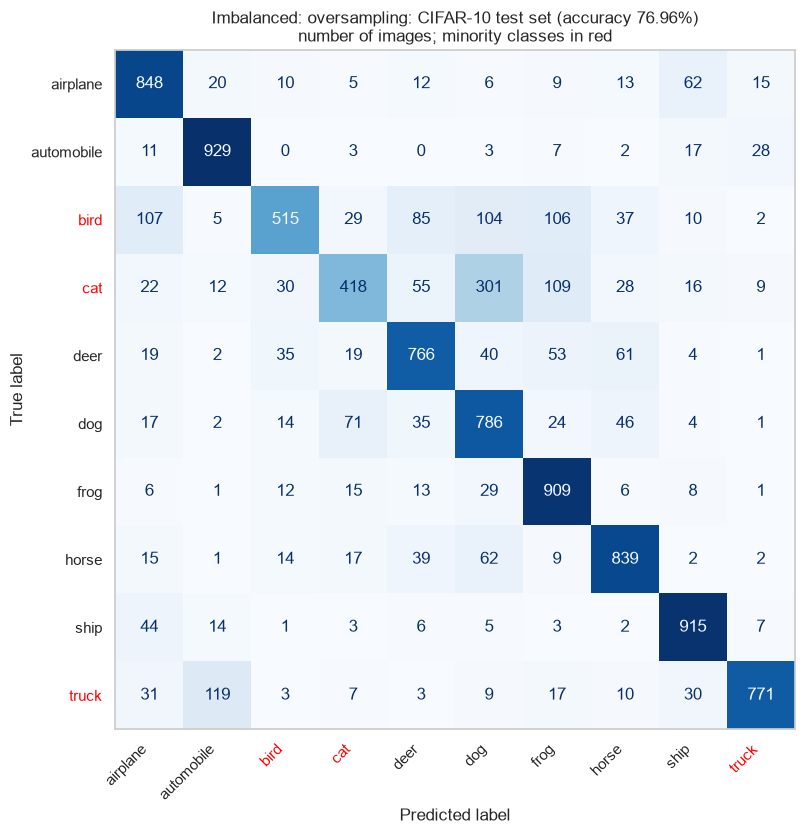

  bird: 515 / 1000 correct; most often mistaken for airplane (107 images)
   cat: 418 / 1000 correct; most often mistaken for dog (301 images)
 truck: 771 / 1000 correct; most often mistaken for automobile (119 images)



In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

imb_runs = {"Imbalanced: baseline": "cifar_imb_baseline",
            "Imbalanced: class-weighted loss": "cifar_imb_weighted",
            "Imbalanced: oversampling": "cifar_imb_oversample"}

for label, run in imb_runs.items():
    # Load this method's best model and predict the 10,000 test images
    m = CifarCNN().to(device)
    m.load_state_dict(torch.load(MODEL_DIR / f"{run}_best.pt", map_location=device))
    y_t, y_p, _ = get_predictions(m, cifar_test_loader)

    # One figure per method
    cm = confusion_matrix(y_t, y_p)                              # counts: rows = true, columns = predicted
    fig, ax = plt.subplots(figsize=(10, 8.5))
    ConfusionMatrixDisplay(cm, display_labels=CIFAR_CLASSES).plot(
        ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.grid(False)                                               # no grid lines over the numbers
    ax.set_title(f"{label}: CIFAR-10 test set (accuracy {accuracy_score(y_t, y_p):.2%})\n"
                 f"number of images; minority classes in red")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for tick in ax.get_xticklabels() + ax.get_yticklabels():     # minority class names in red
        if tick.get_text() in MINORITY_CLASSES:
            tick.set_color("red")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{run}_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Summary for the minority classes: how many were correct, and where most mistakes went
    for c in minority_ids:
        row = cm[c].copy()
        correct = row[c]
        row[c] = 0                                               # ignore the correct ones to find the top mistake
        print(f"{CIFAR_CLASSES[c]:>6}: {correct} / 1000 correct; most often mistaken for "
              f"{CIFAR_CLASSES[row.argmax()]} ({row.max()} images)")
    print()
